<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 1 · Linear & Logistic Regression</h4>
<h1 align="center">Linear Regression — Avocado Prices</h1>
<p align="center"><i>Why avocado toast got expensive -- an exploratory tour of the cleaned data</i></p>

---

## Why We Start With the Data, Not the Model

It is tempting to treat exploratory data analysis as a formality -- a few plots to satisfy a
checklist before the "real work" of fitting a model begins. That framing is backwards, and it
is worth stating plainly why.

A regression model is, at its core, a very disciplined way of describing a pattern that is
**already present in the data**. It cannot invent a relationship between `Total Volume` and
`AveragePrice` if none exists; it can only find and quantify a signal that is really there. If
the signal is weak, noisy, non-linear, or contaminated by a structural quirk we don't
understand, no amount of algorithmic sophistication in Chapter 3 will rescue us. The data
determines the ceiling on what any model -- linear regression, gradient boosting, or a neural
network -- can achieve. The choice of model determines how close we get to that ceiling.

There is a second, more practical reason to look before we model: **trust**. A coefficient of
"+0.05 per 1,000 units of `Total Volume`" is meaningless unless we know the scale, the
distribution, and the units of `Total Volume` well enough to sanity-check that number against
intuition. A model we don't understand the inputs to is a model we cannot debug, explain to a
stakeholder, or trust in production. Every plot in this notebook exists to build exactly that
kind of informed skepticism before a single `LinearRegression().fit()` call happens.

> **The philosophy, in one sentence:** we are not decorating the modeling step with pictures --
> we are earning the right to model at all, by first understanding the shape, scale, and quirks
> of the thing we're trying to predict.

This is also just a genuinely fun dataset to dig into. Somewhere in these charts is the answer
to a question everyone has an opinion about: **why did avocado toast get so expensive?**


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("data")
df = pd.read_csv(DATA_DIR / "avocado_clean.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Shape: {df.shape}")
df.head()


Shape: (18244, 13)


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-01-04,1.64,1505.12,1.27,1129.50,0.00,374.35,186.67,187.68,0.0,organic,2015,Boise
1,2015-01-04,1.18,22630.58,13175.57,9028.34,0.00,426.67,426.67,0.00,0.0,organic,2015,SanFrancisco
2,2015-01-04,1.09,3759282.62,126640.65,2860709.93,7580.38,764351.66,669970.50,94381.16,0.0,conventional,2015,Northeast
3,2015-01-04,1.49,33795.91,6821.76,20720.77,1.23,6252.15,452.73,5799.42,0.0,organic,2015,Seattle
4,2015-01-04,1.39,4414.29,56.21,2760.82,0.00,1597.26,1139.42,457.84,0.0,organic,2015,Roanoke


## 1. Price Over Time

Let's start with the single most natural question about a "prices" dataset: what did the
average price actually *do* over the ~4 years of data we have (2015-2018)? We aggregate to a
monthly average across all regions and both `type`s to get a clean macro trend line.


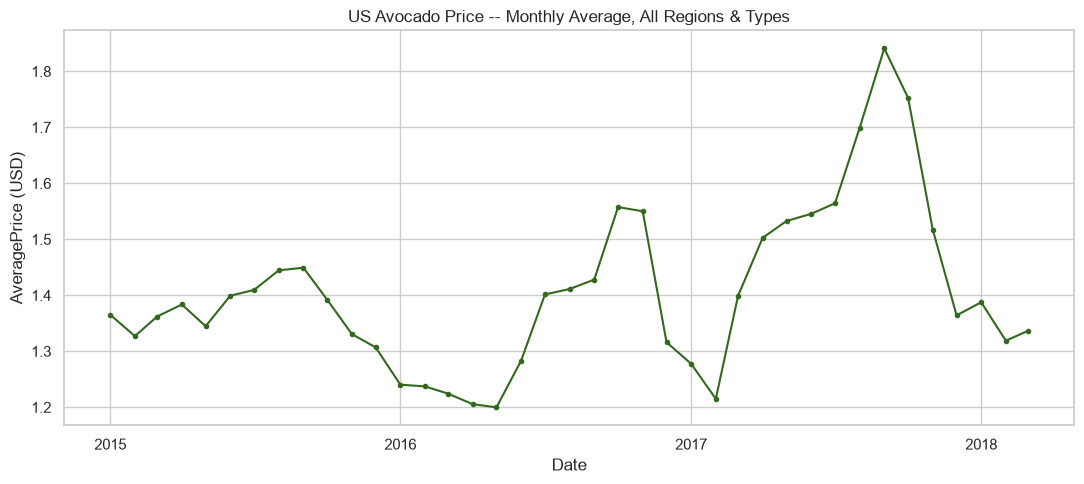

In [2]:
monthly = (
    df.set_index("Date")["AveragePrice"]
    .resample("MS")
    .mean()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, marker="o", markersize=3, color="#33691e", linewidth=1.5)
ax.set_title("US Avocado Price -- Monthly Average, All Regions & Types")
ax.set_xlabel("Date")
ax.set_ylabel("AveragePrice (USD)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


> **Reading this chart:** there is a visible seasonal wobble within most years plus a broad
> upward drift toward 2017, followed by a partial pullback. This immediately tells us `Date`
> (or features derived from it, like `year` and `month`) is likely to carry real predictive
> signal -- price is not stationary over this window. It also means a **naive random
> train/test split risks leaking future price levels into the training set**, a point we will
> come back to explicitly in the data-processing notebook.


## 2. `AveragePrice` by `type` -- Organic vs. Conventional

One of the first things anyone who buys avocados already suspects: organic costs more. Let's
quantify it.


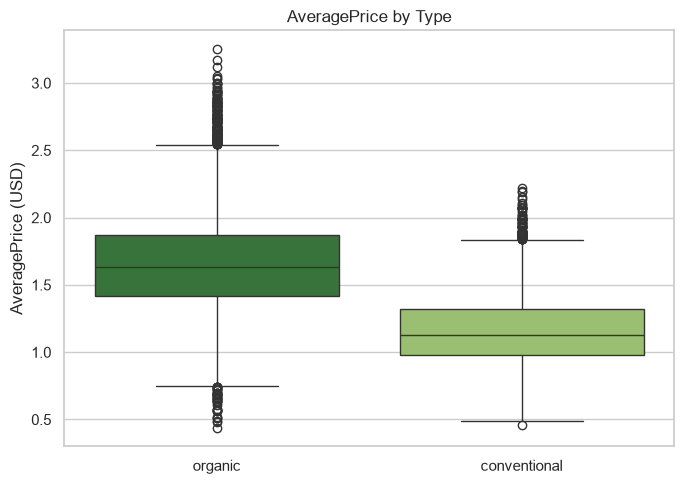

,mean,median,std
type,,,
conventional,1.158,1.13,0.263
organic,1.654,1.63,0.364


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="type", y="AveragePrice", hue="type", palette={"conventional": "#9ccc65", "organic": "#2e7d32"}, ax=ax, legend=False)
ax.set_title("AveragePrice by Type")
ax.set_xlabel("")
ax.set_ylabel("AveragePrice (USD)")
plt.tight_layout()
plt.show()

df.groupby("type")["AveragePrice"].agg(["mean", "median", "std"]).round(3)


> **Interpretation:** the two boxes barely overlap. `type` looks like it will be one of the
> single strongest predictors we have -- a categorical feature that shifts the price
> distribution by roughly \$0.40-0.50 on its own, before we even consider volume or region.
> This is a good sign for the model: a clean, large, well-separated categorical effect is easy
> for linear regression to capture with a single coefficient.


## 3. `AveragePrice` Across the Top Regions by Volume

Price is not just a national number -- different metro regions have structurally different
price levels (rents, local supply chains, distance from ports). We look at the top 10
*granular* regions by total volume moved (excluding aggregate rollups like `TotalUS`, which we
will discuss properly in the next chart) to see how much regional variation exists.


Top 10 granular regions by total volume: ['LosAngeles', 'NewYork', 'DallasFtWorth', 'Houston', 'PhoenixTucson', 'Denver', 'SanFrancisco', 'BaltimoreWashington', 'Chicago', 'Portland']


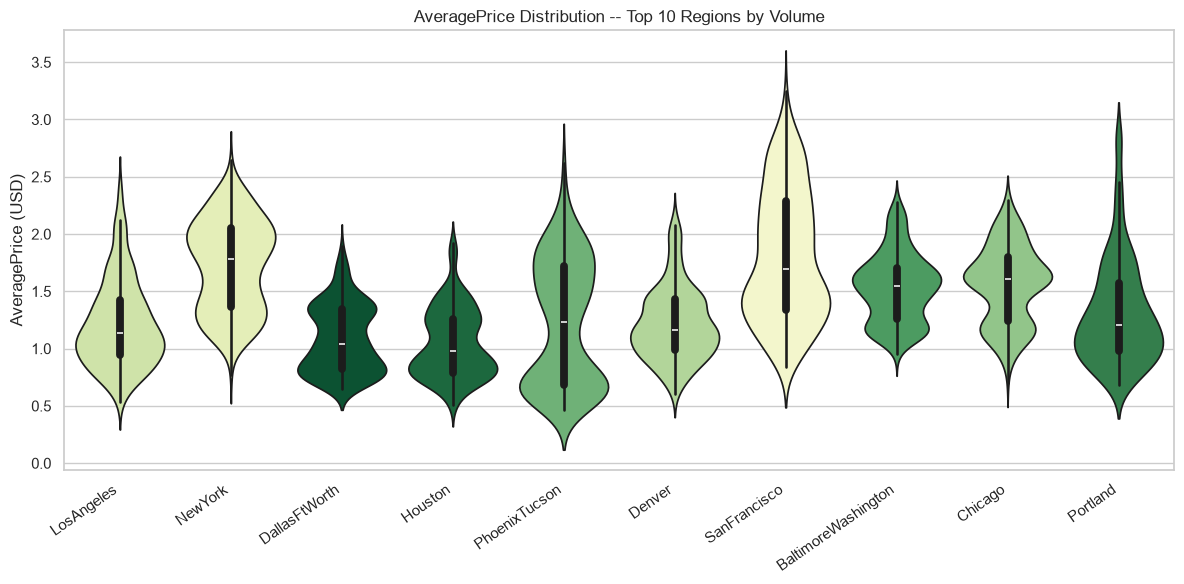

In [4]:
AGGREGATE_REGIONS = [
    "TotalUS", "California", "GreatLakes", "Midsouth", "Northeast",
    "NorthernNewEngland", "Plains", "SouthCentral", "Southeast",
    "West", "WestTexNewMexico",
]

granular = df[~df["region"].isin(AGGREGATE_REGIONS)]
top_regions = (
    granular.groupby("region")["Total Volume"].sum().sort_values(ascending=False).head(10).index.tolist()
)
print("Top 10 granular regions by total volume:", top_regions)

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=granular[granular["region"].isin(top_regions)],
    x="region", y="AveragePrice", hue="region", order=top_regions,
    palette="YlGn", ax=ax, legend=False,
)
ax.set_title("AveragePrice Distribution -- Top 10 Regions by Volume")
ax.set_xlabel("")
ax.set_ylabel("AveragePrice (USD)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


> **Interpretation:** even among the highest-volume markets, typical prices differ by
> several tens of cents, and some regions (look for the widest violins) show far more
> week-to-week volatility than others. This tells us `region` is not a redundant feature once
> we already have `Total Volume` -- it captures a location effect that volume alone does not
> explain, and it justifies giving `region` its own set of one-hot columns in the modeling
> notebook rather than dropping it as "just noise."


## 4. Price vs. Volume -- the Core Economic Relationship

Basic economics says price and quantity sold should be negatively related, all else equal
(more supply, lower price). `Total Volume` spans several orders of magnitude, so we plot it on
a log scale to see the relationship clearly.


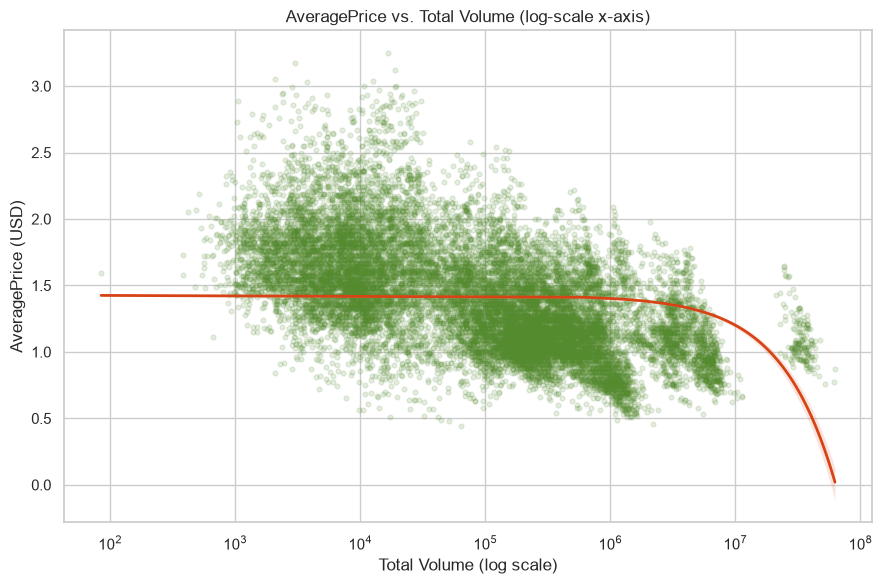

Correlation between log10(Total Volume) and AveragePrice: -0.583


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(
    data=df, x="Total Volume", y="AveragePrice",
    scatter_kws={"alpha": 0.15, "s": 12, "color": "#558b2f"},
    line_kws={"color": "#d84315", "linewidth": 2},
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("AveragePrice vs. Total Volume (log-scale x-axis)")
ax.set_xlabel("Total Volume (log scale)")
ax.set_ylabel("AveragePrice (USD)")
plt.tight_layout()
plt.show()

corr = np.corrcoef(np.log10(df["Total Volume"]), df["AveragePrice"])[0, 1]
print(f"Correlation between log10(Total Volume) and AveragePrice: {corr:.3f}")


> **Interpretation:** there is a real, negative trend -- high-volume weeks/regions tend to
> have lower average prices, consistent with basic supply-and-demand intuition. Note, though,
> how wide the vertical scatter is at any given volume level: volume alone leaves a lot of
> price variation unexplained. This previews a key result we will see again in notebook 03 --
> `Total Volume` is a genuinely useful predictor, but not sufficient by itself, which is why
> `type`, `region`, and time features all earn a place in the final feature set.


## 5. Correlation Heatmap -- Numeric Columns

Before modeling, we need to know which numeric columns are actually independent sources of
information versus which are just re-expressions of each other.


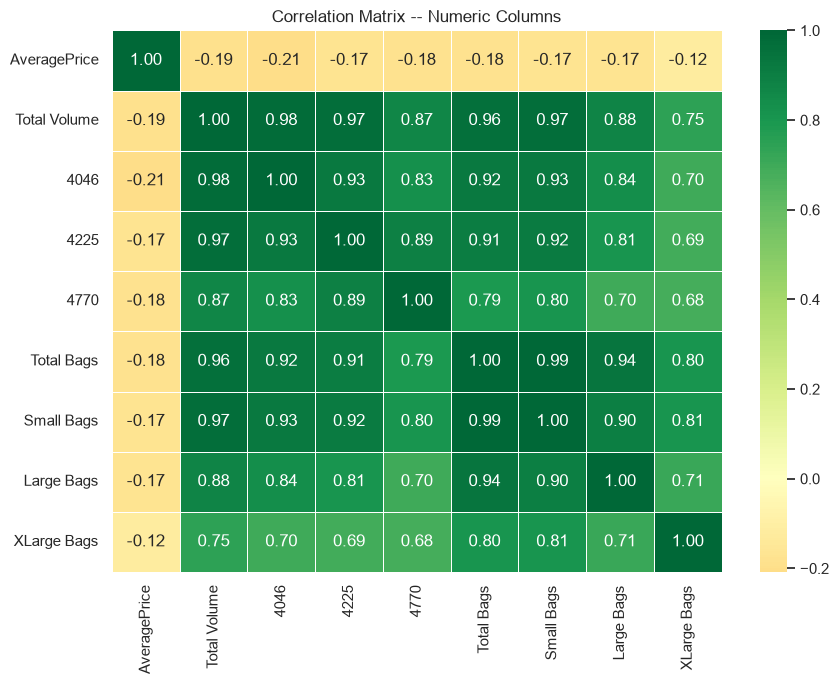

In [6]:
numeric_cols = ["AveragePrice", "Total Volume", "4046", "4225", "4770",
                 "Total Bags", "Small Bags", "Large Bags", "XLarge Bags"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix -- Numeric Columns")
plt.tight_layout()
plt.show()


> **The multicollinearity gotcha:** `Total Volume` is, by construction, almost exactly the
> sum of `4046 + 4225 + 4770 + Total Bags`, and `Total Bags` is itself almost exactly
> `Small Bags + Large Bags + XLarge Bags`. That's exactly why the heatmap shows correlations
> above 0.90 (often above 0.95) among most of these columns -- they are not nine independent
> measurements, they are closer to two or three independent measurements expressed nine
> different ways.
>
> This matters a great deal for **linear** regression specifically: feeding highly collinear
> columns into an OLS fit doesn't necessarily hurt predictive accuracy much, but it makes the
> individual **coefficients** unstable and difficult to interpret -- small changes in the data
> can swing a coefficient's sign. We will quantify this properly with the **Variance Inflation
> Factor (VIF)** in notebook 03, and it is the reason a careful feature-selection pass belongs
> in the data-processing step rather than "throw every numeric column at the model and hope."


## 6. A Note on `region`'s Hierarchy -- a Real-World Double-Counting Trap

Look back at the region list in the raw data and you'll notice 54 distinct values, but they
are **not all peers**. Several of them are aggregate rollups that already contain the volume
of other rows in the same column:

- `TotalUS` is the sum of essentially every other region.
- `California`, `GreatLakes`, `Midsouth`, `Northeast`, `NorthernNewEngland`, `Plains`,
  `SouthCentral`, `Southeast`, `West`, and `WestTexNewMexico` are multi-city/multi-state
  aggregate groupings, not additional independent markets.

We can see this directly by comparing volumes on a single date/type combination.


In [7]:
snapshot = df[(df["Date"] == df["Date"].max()) & (df["type"] == "conventional")]
snapshot = snapshot[["region", "Total Volume"]].sort_values("Total Volume", ascending=False)
snapshot.head(12)


,region,Total Volume
18184,TotalUS,43409835.75
18240,SouthCentral,9010588.32
18136,West,7667064.46
18201,California,6687009.44
18189,Northeast,5134637.05
18172,Southeast,4454904.40
18157,GreatLakes,4245947.20
18203,Midsouth,3911075.35
18213,LosAngeles,2843541.07
18182,Plains,2298609.62


> **Why this is a genuine data-integrity gotcha, not a modeling nitpick:** if we treat every
> value of `region` as an equally-weighted independent observation -- which is exactly what
> `pd.get_dummies` plus a plain train/test split would do -- we are silently **double, triple,
> or even quadruple counting** the same underlying sales activity. `TotalUS` volume already
> contains `California`'s volume, which already contains `LosAngeles`'s volume. A model
> trained naively on all 54 region rows isn't looking at 54 independent markets; a meaningful
> chunk of its training rows are arithmetic restatements of other training rows.
>
> We are **not** going to "fix" this in this EDA notebook -- fixing it is a modeling decision,
> and it belongs in the data-processing notebook, where we will make an explicit, justified
> choice about which rows to keep. The job of EDA is simply to notice the trap before it bites
> us.


## 7. An Interactive View -- Price by Region and Year (Plotly)

Static charts are great for a fixed question, but this dataset has a natural third dimension
(time) that rewards an interactive explorer. Below, each frame is a year; hover over any bar
to see the exact average price for that region.


In [8]:
agg = (
    granular.groupby(["region", "year"])["AveragePrice"]
    .mean()
    .reset_index()
)
order = granular.groupby("region")["Total Volume"].sum().sort_values(ascending=False).index.tolist()

fig = px.bar(
    agg, x="region", y="AveragePrice", color="AveragePrice",
    animation_frame="year", category_orders={"region": order},
    color_continuous_scale="YlGn",
    title="Average Avocado Price by Region -- Animated by Year",
    labels={"AveragePrice": "Avg. Price (USD)"},
    height=550,
)
fig.update_layout(xaxis_tickangle=-45, xaxis_title="", margin=dict(b=140))
fig.show()


> **Interpretation:** scrub through the years and watch which regions jump the most --
> that's the interactive advantage over a static faceted grid: the eye can track a single
> region's trajectory across frames far more easily than across a 4x14 grid of tiny subplots.
> Notice that price levels are far from uniform across the country even within a single year,
> reinforcing the region-effect story from Section 3.


In [9]:
fig3d = px.scatter_3d(
    df.sample(2500, random_state=42),
    x="Total Volume", y="Total Bags", z="AveragePrice",
    color="type", opacity=0.5,
    color_discrete_map={"conventional": "#9ccc65", "organic": "#1b5e20"},
    title="Total Volume vs. Total Bags vs. AveragePrice (2,500-row sample)",
    height=600,
)
fig3d.update_scenes(xaxis_type="log", yaxis_type="log")
fig3d.show()


> **Interpretation:** rotate the cube and you can see organic (dark green) points cluster at
> higher `AveragePrice` values across the full range of volume, while the two volume axes
> (`Total Volume`, `Total Bags`) are visibly correlated with each other -- points roughly track
> a diagonal plane rather than filling the cube, which is the same collinearity we already
> quantified numerically in Section 5, just visible geometrically now.


## Summary -- What EDA Told Us Before We Touch a Model

- Price has genuine **time structure** (trend and seasonality), so date-derived features and
  a time-aware evaluation mindset both matter.
- `type` is a strong, cleanly-separated predictor -- organic commands a substantial premium.
- `region` carries real signal beyond what `Total Volume` explains, but its 54 values include
  **aggregate rollups that double-count** granular regions -- a data-integrity issue we will
  resolve explicitly in the next notebook, not paper over here.
- `Total Volume` and `AveragePrice` have the expected negative relationship, but with enough
  scatter that volume alone will not be a sufficient model.
- The volume-related numeric columns (`Total Volume`, the PLU columns, and the bag columns)
  are severely **multicollinear** -- a fact that will shape both our feature-selection choices
  in preprocessing and our interpretation of coefficients in the modeling notebook.

**Next up:** `02_data_processing.ipynb` turns these observations into a modeling-ready
feature matrix.
